# Init

## Installs

In [40]:
!pip install pillow matplotlib numpy

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------------ --------- 6.3/8.3 MB 30.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 27.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 28.9 MB/s  0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   --------------------- ------------------ 6.6/12.4 MB 30.8 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.4 MB 30.0 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 28.0 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [nump


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [1]:
import os
import json
import random

from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

## Load Data

In [2]:
img_dir = os.path.join(os.path.dirname(os.getcwd()), "data", "bdd", "images", "100k", "test")
json_dir = os.path.join(os.path.dirname(os.getcwd()), "data", "bdd", "labels", "100k", "test")

In [5]:
n = 50000

In [9]:
# load 5 random images from data/images/100k/test
with os.scandir(img_dir) as it:
    all_img_names = [os.path.splitext(entry.name)[0] for entry in it if entry.is_file() and entry.name.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
# Randomly pick N names
if n>=len(all_img_names):
    selected_names = all_img_names
else:
    selected_names = random.sample(all_img_names, n)

selected_images = []
labels = []

for name in selected_names:
    # 1. Fix for Images: Use .copy() to load data into memory and close the handle
    img_path = os.path.join(img_dir, f"{name}.jpg")
    with Image.open(img_path) as img:
        selected_images.append(img.copy()) 

    # 2. Fix for JSON: Use a context manager
    json_path = os.path.join(json_dir, f"{name}.json")
    with open(json_path, "r") as f:
        labels.append(json.load(f))

print(f"Successfully loaded {len(selected_images)} images and labels.")

Successfully loaded 20000 images and labels.


In [10]:
def get_unique_labels(labels_data):
    unique_categories = set()

    for entry in labels_data:
        # Navigate to the objects list for the first frame
        # We use .get() or checks to avoid KeyErrors if a frame is empty
        if "frames" in entry and len(entry["frames"]) > 0:
            objects = entry["frames"][0].get("objects", [])
            
            for obj in objects:
                cat = obj.get("category")
                if cat:
                    unique_categories.add(cat)
                    
    return sorted(list(unique_categories))

# Usage:
all_categories = get_unique_labels(labels)
print(f"Found {len(all_categories)} unique categories:")
all_categories

Found 20 unique categories:


['area/alternative',
 'area/drivable',
 'bike',
 'bus',
 'car',
 'lane/crosswalk',
 'lane/double other',
 'lane/double white',
 'lane/double yellow',
 'lane/road curb',
 'lane/single other',
 'lane/single white',
 'lane/single yellow',
 'motor',
 'person',
 'rider',
 'traffic light',
 'traffic sign',
 'train',
 'truck']

# Visualize data

In [15]:
def visualize_bdd_with_metadata(img, labels, SHOW_DETAILS=False, COVER_AREAS=False):
    """
    Visualizes BDD100K labels with all associated attribute metadata.
    """
    fig, ax = plt.subplots(figsize=(20, 12))
    ax.imshow(img)
    
    colors = {
        'car': '#FF3838',           # Red
        'truck': '#1CF237',         # Green
        'bike': '#21D4FF',          # Cyan
        'bus': '#3357FF',           # Blue
        'motor': '#FF21F2',         # Pink/Magenta
        'person': '#00FFFF',        # Aqua
        'rider': '#FFA500',         # Orange
        'traffic light': '#FFFF00', # Bright Yellow
        'traffic sign': '#FFB21D',  # Yellow/Orange
        # 'area': '#21D4FF',
        'lane': '#C521FF'           # Purple
    }

    for label in labels:
        category = label['category']
        obj_id = label['id']
        attributes = label.get('attributes', {})
        
        # Color logic
        base_cat = category.split('/')[0] if '/' in category else category
        color = colors.get(category, colors.get(base_cat, 'white'))
        if base_cat not in colors:
            print(f"class {base_cat} not in color code list")
        
        # Construct the metadata string: Class and ID first
        meta_text = f"{category.upper()} | ID: {obj_id}"
        if SHOW_DETAILS:
            for key, val in attributes.items():
                meta_text += f"\n{key}: {val}"

        # 1. Handle Bounding Boxes (Points/Rects)
        if 'box2d' in label:
            box = label['box2d']
            x1, y1, x2, y2 = box['x1'], box['y1'], box['x2'], box['y2']
            
            # Draw Box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, 
                                     edgecolor=color, facecolor='none', alpha=0.9)
            ax.add_patch(rect)
            
            # Draw Label Background and Text
            ax.text(x1, y1 - 2, meta_text, color='white', fontsize=7, 
                    fontweight='bold', verticalalignment='bottom',
                    bbox=dict(facecolor=color, alpha=0.7, lw=0, pad=1))

        elif COVER_AREAS:
            # 2. Handle Polygons/Lines (Areas/Lanes)
            if 'poly2d' in label:
                poly_data = label['poly2d']
                points = np.array([[p[0], p[1]] for p in poly_data])
                # Logic for plotting the shape
                is_area = 'area' in category
                poly_shape = patches.Polygon(points, closed=is_area, linewidth=2, 
                                            edgecolor=color, facecolor=color if is_area else 'none', 
                                            alpha=0.25 if is_area else 0.7)
                ax.add_patch(poly_shape)
                
                # Place metadata at the first point of the polygon
                ax.text(points[0][0], points[0][1], meta_text, color='white', fontsize=7, 
                        fontweight='bold', bbox=dict(facecolor=color, alpha=0.7, lw=0, pad=1))

    plt.axis('off')
    plt.show()

displaying index 7901
class area not in color code list


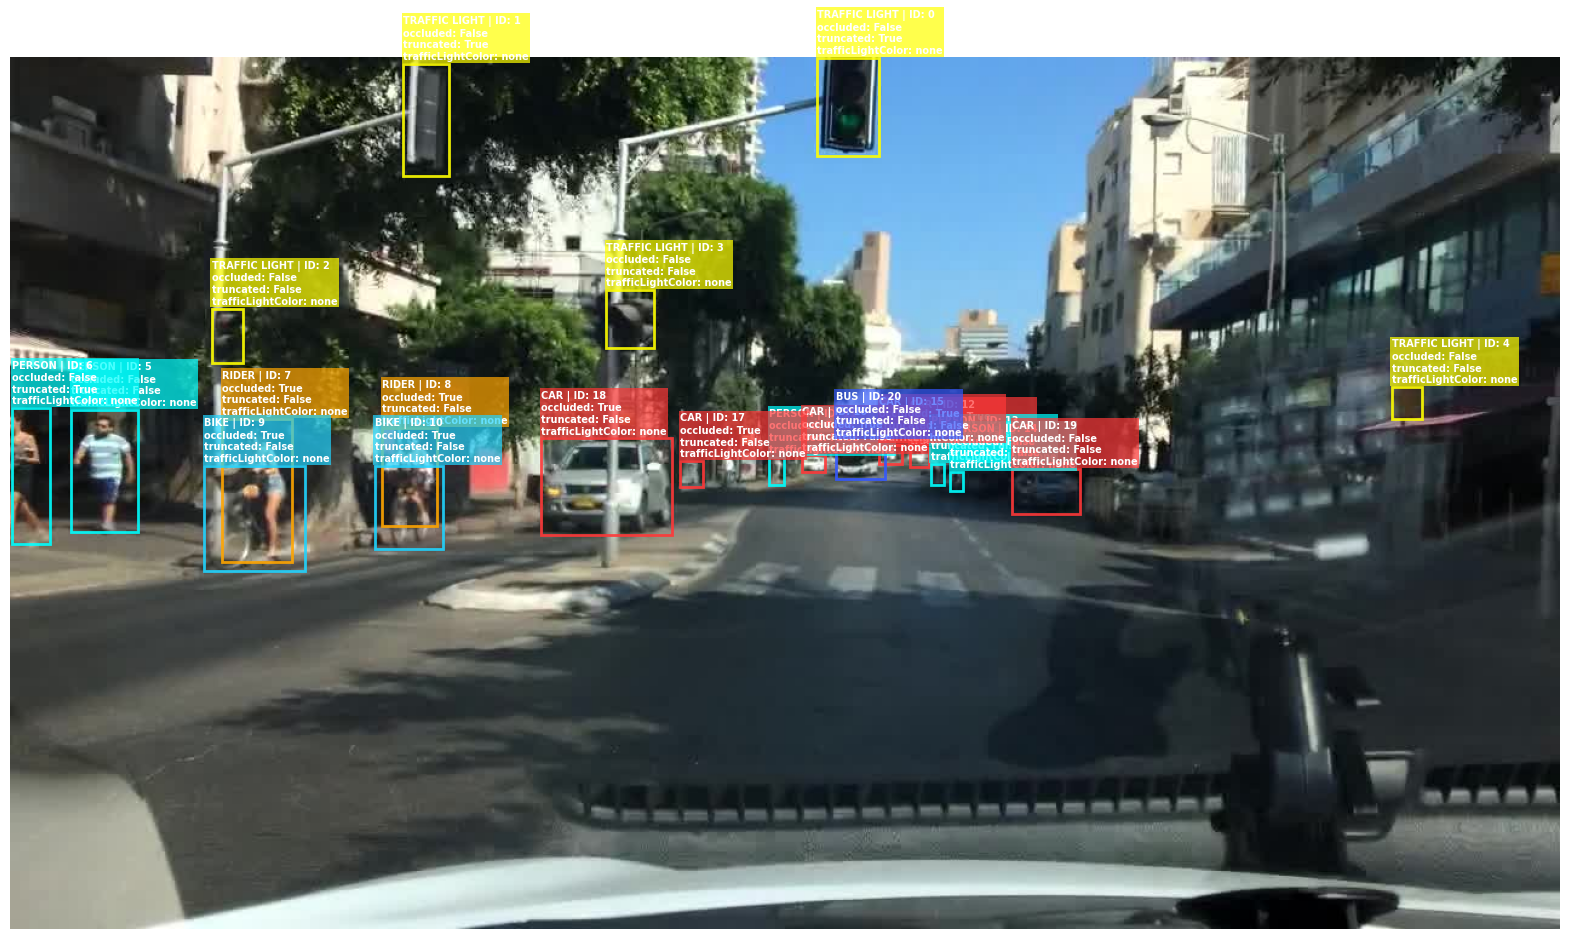

In [115]:
# show
index = random.randint(0, len(selected_images))
print(f"displaying index {index}")

visualize_bdd_with_metadata(selected_images[index], labels[index]["frames"][0]["objects"], SHOW_DETAILS=True)